In [4]:
# ── Cell 1: load results ─────────────────────────────────────────────────────
import glob
import pandas as pd

OUTPUT_CSV = "./results/results_dp_sbm_polblogs.csv"   # match OUTPUT_CSV in script_polblogs.py

shard_files = sorted(glob.glob(f"{OUTPUT_CSV}.shard*"))
if shard_files:
    df = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
    print(f"Loaded {len(shard_files)} shard files, {len(df)} rows total.")
else:
    df = pd.read_csv(OUTPUT_CSV)
    print(f"Loaded {OUTPUT_CSV}, {len(df)} rows.")

# ── Drop the sigma=0.1 grid point ──────────────────────────────────────────
# At sigma=0.1 the accountant returns epsilon ~ 1605 (1.6e+03). np.exp(epsilon)
# in edge_flip/p_flip overflows float64 there (exp overflows above ~709.8), so
# that point's beta/NMI values are unreliable. It is also no privacy at all
# (epsilon in the thousands), so it carries no information -- exclude it from
# every plot below.
_n_before = len(df)
df = df[df["sigma"] != 0.1].reset_index(drop=True)
print(f"Excluded sigma=0.1 (epsilon~1.6e+03, overflow): dropped {_n_before - len(df)} rows, {len(df)} remain.")

df.head()

Loaded ./results/results_dp_sbm_polblogs.csv, 240 rows.
Excluded sigma=0.1 (epsilon~1.6e+03, overflow): dropped 40 rows, 200 remain.


,N,sigma,epsilon,rep,method,epsilon_gamma,epsilon_beta,epsilon_rho,epochs,epochs_gamma,epochs_beta,delta,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,nmi
0,1222,0.5,75.260893,0,edge_flip_vem,NaN,NaN,NaN,300.000000,NaN,NaN,0.00001,0.042592,0.004226,0.038825,0.002108,0.022182,0.159272,0.000435
1,1222,0.5,75.260893,0,sbm_dpsgd_all_noised,70.772017,12.423111,1.033894,10.999985,5.999992,4.999993,0.00001,0.042592,0.004226,0.038825,0.106011,0.012516,0.142520,0.041655
2,1222,0.5,75.260893,1,edge_flip_vem,NaN,NaN,NaN,288.000000,NaN,NaN,0.00001,0.042592,0.004226,0.038825,0.159272,0.022182,0.002108,0.000435
3,1222,0.5,75.260893,1,sbm_dpsgd_all_noised,70.772017,12.423111,1.033894,10.999985,5.999992,4.999993,0.00001,0.042592,0.004226,0.038825,0.118593,0.004788,0.135494,0.322850
4,1222,0.5,75.260893,2,edge_flip_vem,NaN,NaN,NaN,267.000000,NaN,NaN,0.00001,0.042592,0.004226,0.038825,0.002108,0.022182,0.159272,0.000435


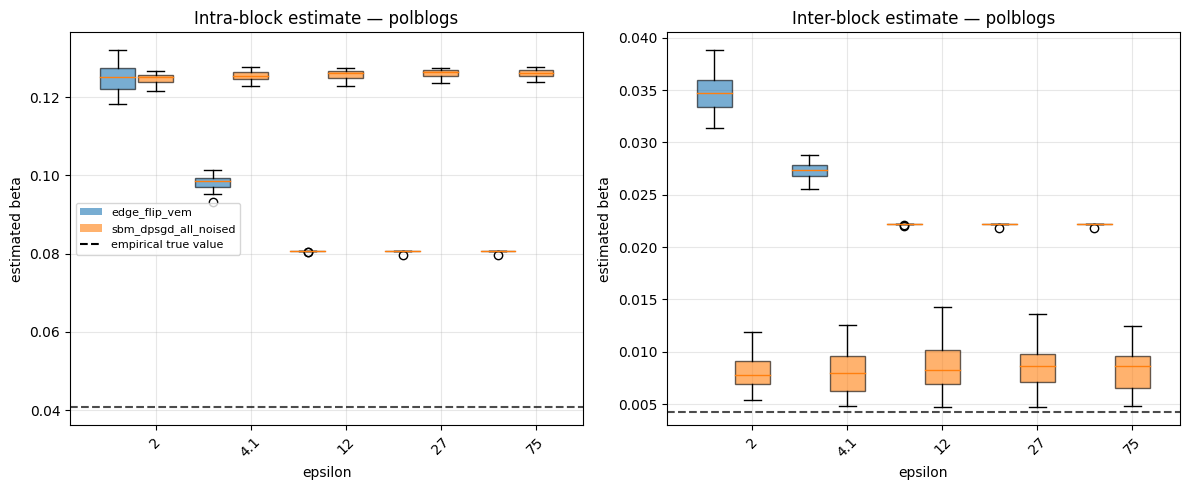

In [5]:
# ── Cell 2: Boxplots of estimated beta vs epsilon ────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

methods = sorted(df["method"].unique())
colors = plt.cm.tab10.colors

eps_vals = sorted(df["epsilon"].unique())
width = 0.8 / len(methods)

true_00 = df["beta_true_00"].iloc[0]
true_01 = df["beta_true_01"].iloc[0]
true_11 = df["beta_true_11"].iloc[0]
df["intra_est"] = df[["beta_est_00", "beta_est_11"]].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (est_col, true_val, title) in zip(axes, [
    ("intra_est", (true_00 + true_11) / 2, "Intra-block estimate"),
    ("beta_est_01", true_01, "Inter-block estimate"),
]):
    data, positions = [], []
    for e_idx, eps in enumerate(eps_vals):
        for m_idx, method in enumerate(methods):
            vals = df[(df["epsilon"] == eps) & (df["method"] == method)][est_col]
            if len(vals) == 0:
                continue
            data.append(vals.values)
            positions.append(e_idx + (m_idx - len(methods) / 2) * width)

    bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
    for patch, i in zip(bp["boxes"], range(len(data))):
        patch.set_facecolor(colors[i % len(methods) % len(colors)])
        patch.set_alpha(0.6)

    ax.axhline(true_val, color="black", linestyle="--", alpha=0.7, linewidth=1.5)
    ax.set_xticks(range(len(eps_vals)))
    ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
    ax.set_title(f"{title} — polblogs")
    ax.set_xlabel("epsilon")
    ax.set_ylabel("estimated beta")
    ax.grid(alpha=0.3)

legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m) for i, m in enumerate(methods)]
legend_elems.append(Line2D([0], [0], color="black", linestyle="--", label="empirical true value"))
axes[0].legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.show()

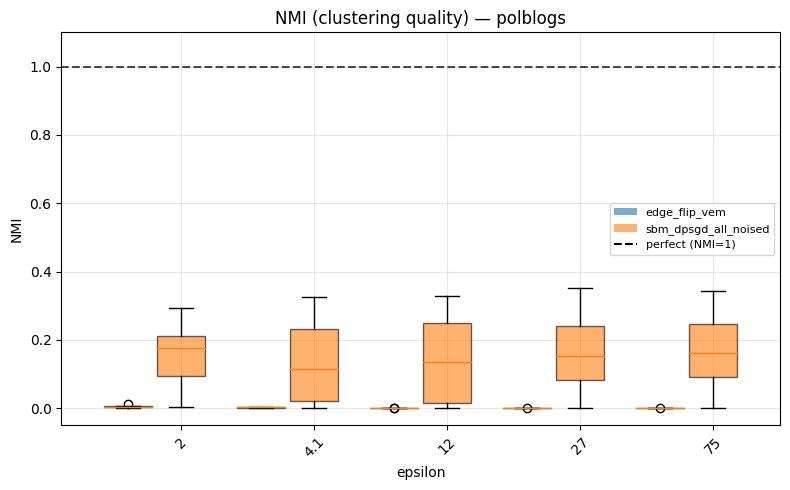

In [6]:
# ── Cell 3: Boxplots of NMI vs epsilon ───────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

methods = sorted(df["method"].unique())
colors = plt.cm.tab10.colors

eps_vals = sorted(df["epsilon"].unique())
width = 0.8 / len(methods)

sub = df.dropna(subset=["nmi"])

fig, ax = plt.subplots(figsize=(8, 5))

data, positions = [], []
for e_idx, eps in enumerate(eps_vals):
    for m_idx, method in enumerate(methods):
        vals = sub[(sub["epsilon"] == eps) & (sub["method"] == method)]["nmi"]
        if len(vals) == 0:
            continue
        data.append(vals.values)
        positions.append(e_idx + (m_idx - len(methods) / 2) * width)

bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
for patch, i in zip(bp["boxes"], range(len(data))):
    patch.set_facecolor(colors[i % len(methods) % len(colors)])
    patch.set_alpha(0.6)

ax.axhline(1.0, color="black", linestyle="--", alpha=0.7, linewidth=1.5)
ax.set_ylim(-0.05, 1.1)
ax.set_xticks(range(len(eps_vals)))
ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
ax.set_title("NMI (clustering quality) — polblogs")
ax.set_xlabel("epsilon")
ax.set_ylabel("NMI")
ax.grid(alpha=0.3)

legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m) for i, m in enumerate(methods)]
legend_elems.append(Line2D([0], [0], color="black", linestyle="--", label="perfect (NMI=1)"))
ax.legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.show()

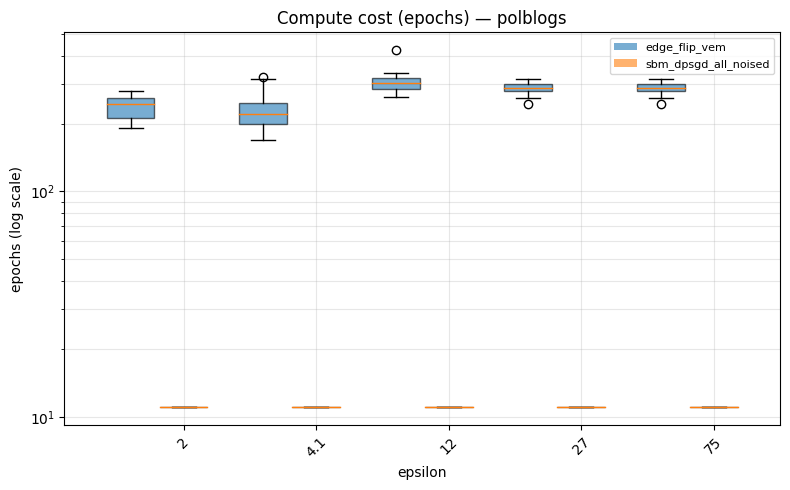

In [7]:
# ── Cell 4: Boxplots of compute cost (epochs) vs epsilon ─────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

methods = sorted(df["method"].unique())
colors = plt.cm.tab10.colors

eps_vals = sorted(df["epsilon"].unique())
width = 0.8 / len(methods)

fig, ax = plt.subplots(figsize=(8, 5))

data, positions = [], []
for e_idx, eps in enumerate(eps_vals):
    for m_idx, method in enumerate(methods):
        vals = df[(df["epsilon"] == eps) & (df["method"] == method)]["epochs"]
        if len(vals) == 0:
            continue
        data.append(vals.values)
        positions.append(e_idx + (m_idx - len(methods) / 2) * width)

bp = ax.boxplot(data, positions=positions, widths=width * 0.9, patch_artist=True)
for patch, i in zip(bp["boxes"], range(len(data))):
    patch.set_facecolor(colors[i % len(methods) % len(colors)])
    patch.set_alpha(0.6)

ax.set_yscale("log")
ax.set_xticks(range(len(eps_vals)))
ax.set_xticklabels([f"{e:.2g}" for e in eps_vals], rotation=45)
ax.set_title("Compute cost (epochs) — polblogs")
ax.set_xlabel("epsilon")
ax.set_ylabel("epochs (log scale)")
ax.grid(alpha=0.3, which="both")

legend_elems = [Patch(facecolor=colors[i % len(colors)], alpha=0.6, label=m) for i, m in enumerate(methods)]
ax.legend(handles=legend_elems, fontsize=8)

plt.tight_layout()
plt.show()